# EDA


In [2]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

raw_data = pd.read_csv('../data/raw/housing/housing.csv')

print(raw_data.head())

   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0        880.0           129.0   
1    -122.22     37.86                21.0       7099.0          1106.0   
2    -122.24     37.85                52.0       1467.0           190.0   
3    -122.25     37.85                52.0       1274.0           235.0   
4    -122.25     37.85                52.0       1627.0           280.0   

   population  households  median_income  median_house_value ocean_proximity  
0       322.0       126.0         8.3252            452600.0        NEAR BAY  
1      2401.0      1138.0         8.3014            358500.0        NEAR BAY  
2       496.0       177.0         7.2574            352100.0        NEAR BAY  
3       558.0       219.0         5.6431            341300.0        NEAR BAY  
4       565.0       259.0         3.8462            342200.0        NEAR BAY  


In [2]:
raw_data.info()
raw_data['ocean_proximity'].value_counts() # Se puede acceder con corchetes o con punto, pero con corchetes se pueden usar caracteres especiales como el guion bajo
# Quiero saber todos los valores posibles de la columna y cuantos hay de cada uno. Es una columna categórica, no numérica. Es importante saber esto para luego poder convertirla a numérica y usarla en el modelo.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

In [3]:
raw_data.describe() # Solo describe las columnas numéricas, no las categóricas. Es importante saber esto para luego convertir las categóricas a numéricas y poder usar esta función para describirlas también.

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [ ]:
# Al tener longitud y latitud, se pueden hacer mapas de calor para ver donde hay más casas, donde hay más casas caras, etc. Esto se puede hacer con la librería folium, que es una librería de mapas para Python. Es importante saber esto para luego poder hacer mapas de calor y visualizaciones geográficas.

path_images = Path()/'images'/'house'
path_images.mkdir(parents=True, exist_ok=True) # Crea la carpeta images/house si no existe, y si ya existe no hace nada. Es importante saber esto para luego poder guardar las imágenes de los mapas de calor y visualizaciones geográficas.

def save_image(name, extension='png', resolution=300):
    path_final = path_images/f'{name}.{extension}'
    plt.tight_layout() # plt es un singletone se instancia solo y no debe pasarse el objeto de la figura, se llama directamente a la función tight_layout() para ajustar el diseño de la figura antes de guardarla.
    plt.savefig(path_final, format=extension, dpi=resolution)

# Un singleton es un patrón de diseño que restringe la instanciación de una clase a un solo objeto. En el caso de matplotlib, plt es un singleton que se instancia automáticamente cuando se importa la librería, por lo que no es necesario crear una instancia de la figura para usar sus funciones.

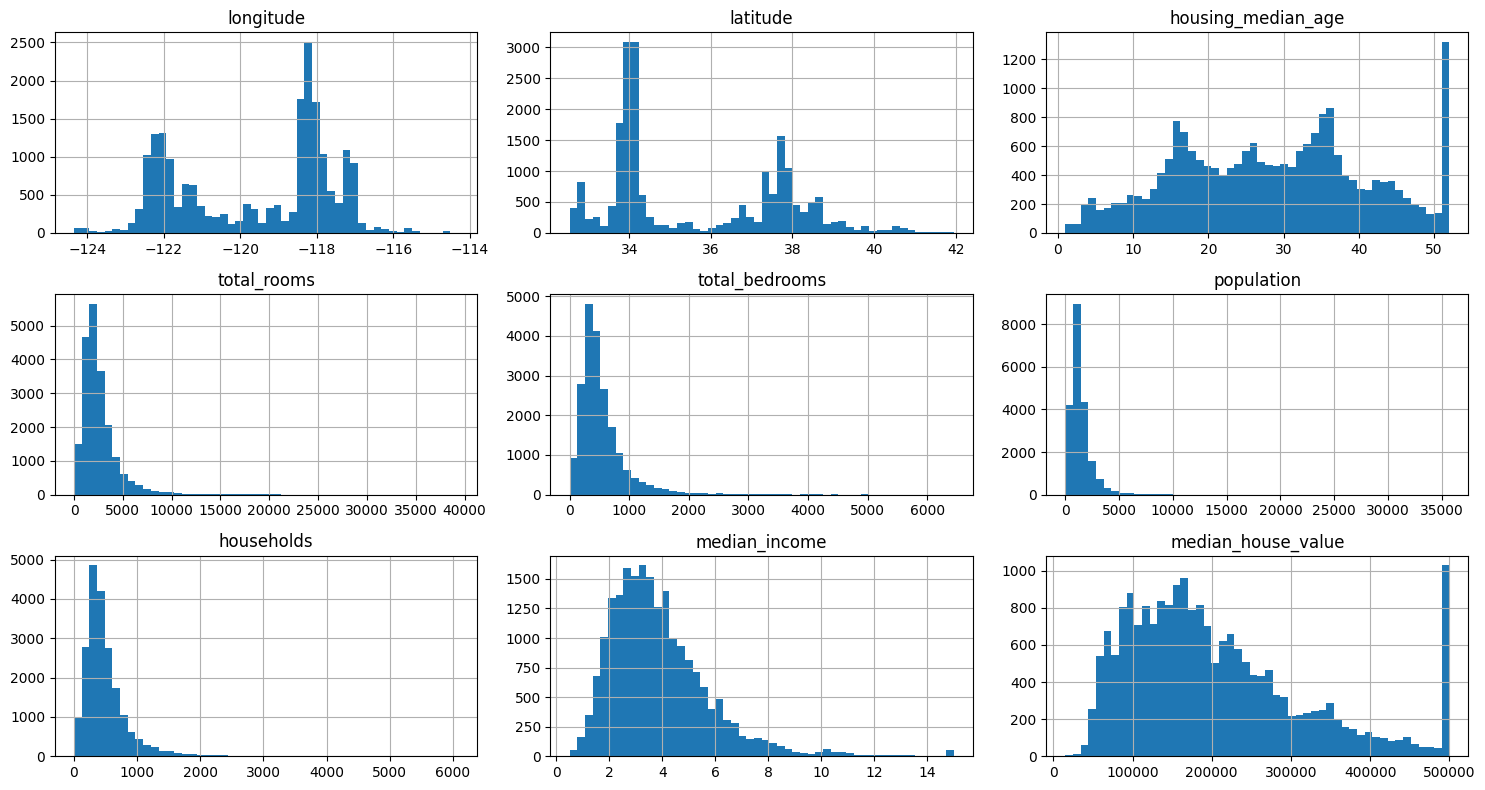

In [9]:
raw_data.hist(bins=50, figsize=(15, 8)) # Raiz de n es la formula para cantdiad de clases

save_image('histogramas')

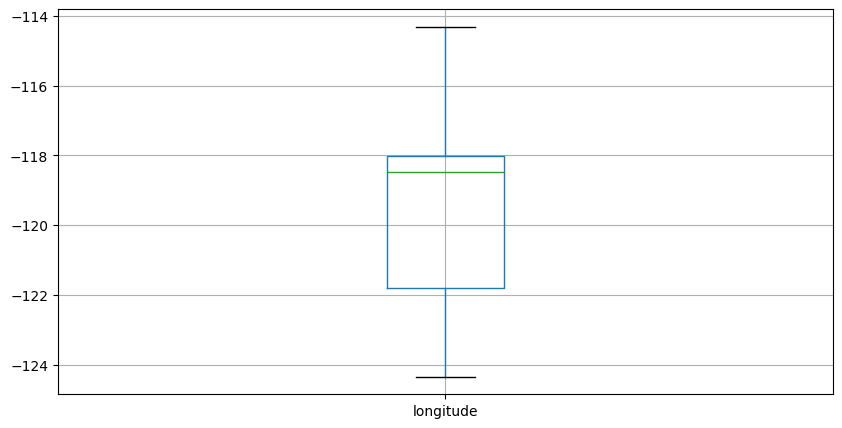

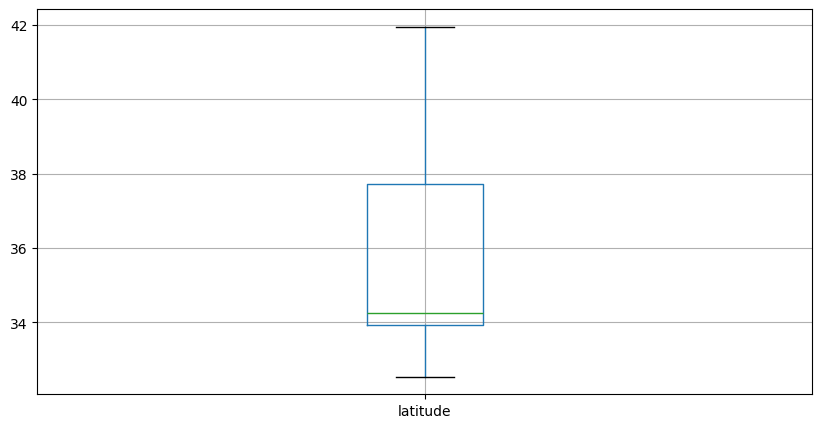

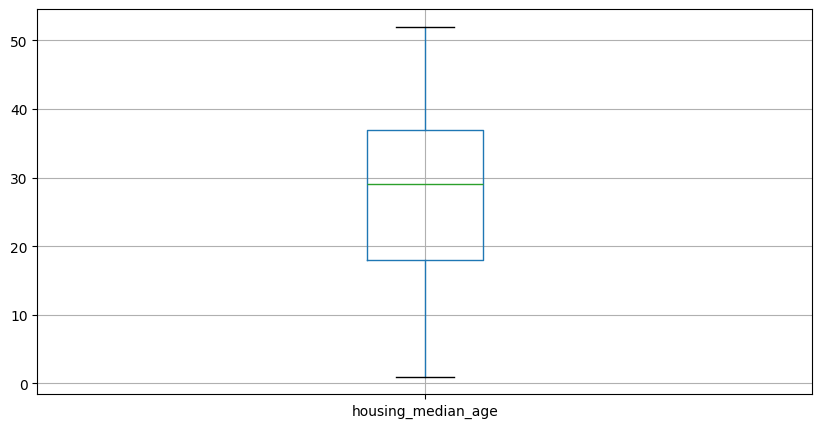

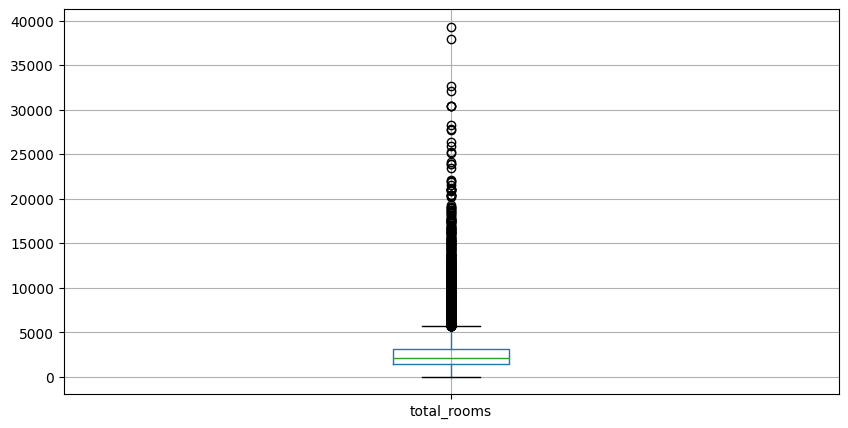

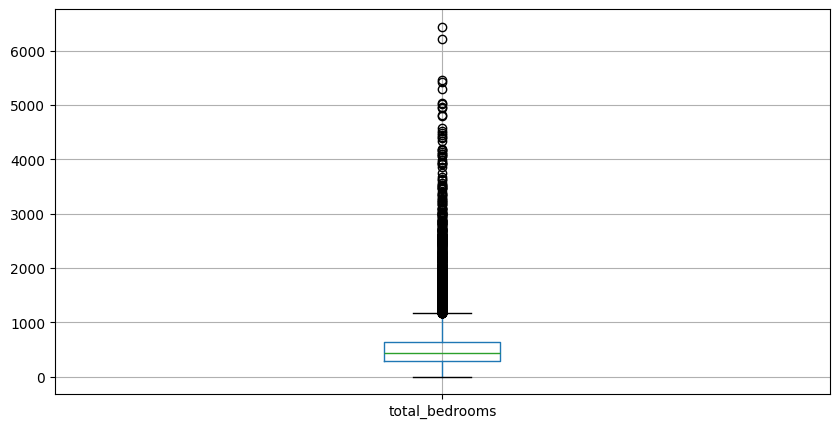

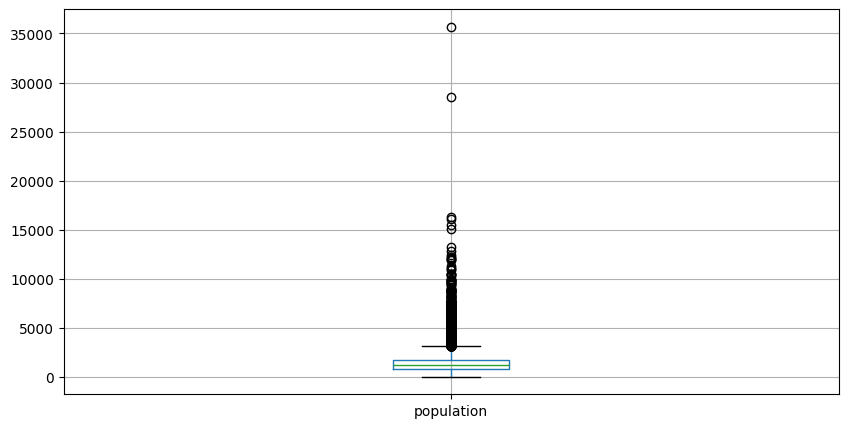

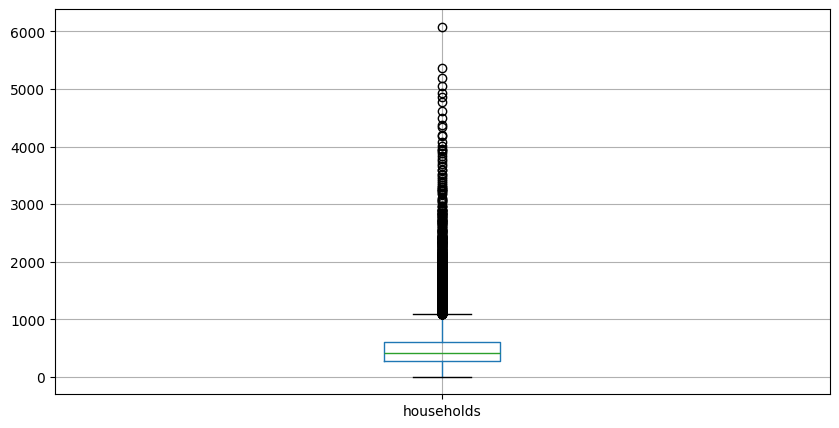

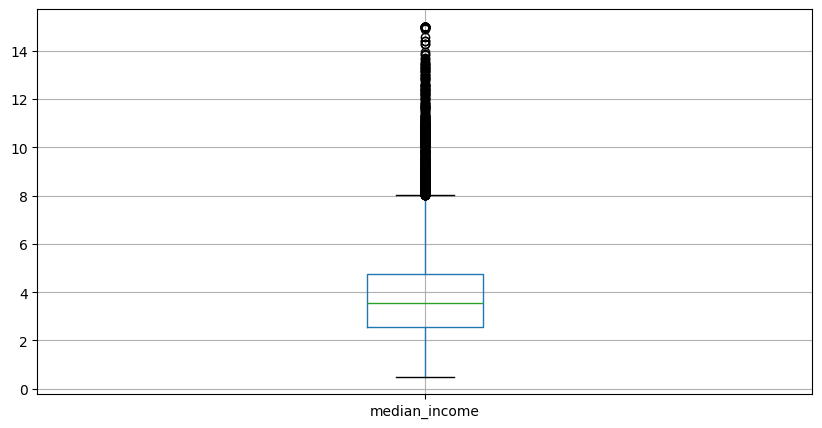

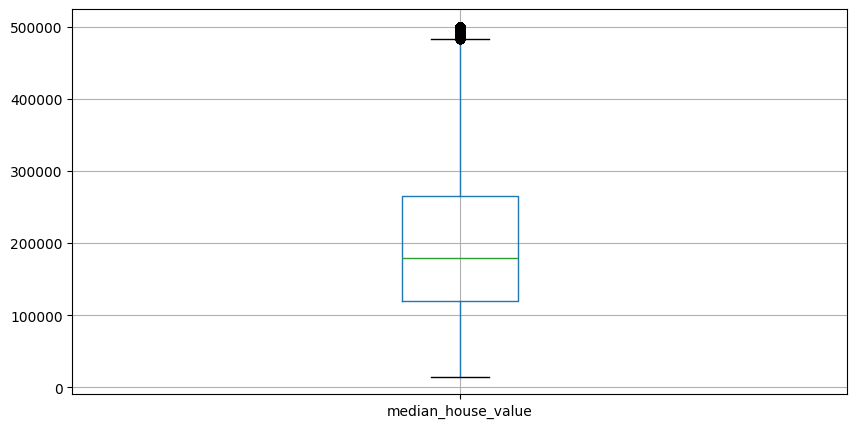

In [14]:
columns_numeric = list(raw_data.columns)[:-1]
for column in columns_numeric: # Excluyo la última columna que es la variable objetivo, no quiero hacer boxplot de esa columna porque es la que quiero predecir, no quiero analizarla como las demás.
    plt.figure(figsize=(10, 5))
    raw_data.boxplot(column=column)

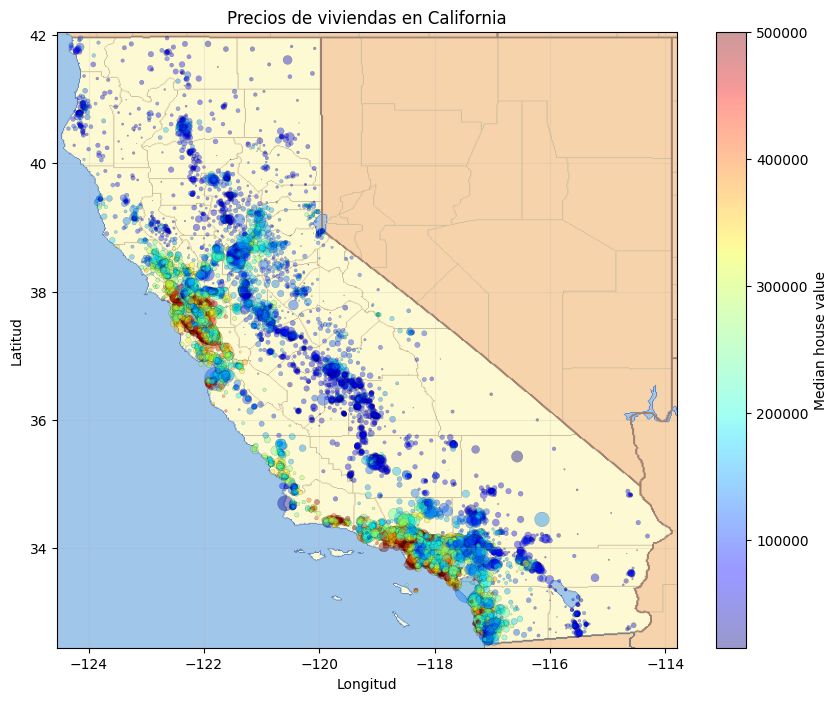

In [9]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from urllib.request import urlopen
from PIL import Image


# URL de la imagen
california_url_image = "https://raw.githubusercontent.com/ageron/handson-ml3/main/images/end_to_end_project/california.png"

# Descargar y leer la imagen
with urlopen(california_url_image) as response:
    california_img = Image.open(response).convert("RGBA")

california_img = np.array(california_img)

# Crear figura
fig, ax = plt.subplots(figsize=(10, 8))

# Mostrar la imagen como fondo
# extent = [xmin, xmax, ymin, ymax]
ax.imshow(
    california_img,
    extent=[-124.55, -113.80, 32.45, 42.05],
    aspect="auto",
    zorder=0
)

# Dibujar los datos encima de la imagen
scatter = ax.scatter(
    raw_data["longitude"],
    raw_data["latitude"],
    s=raw_data["population"] / 100,              # tamaño según población
    c=raw_data["median_house_value"],            # color según precio
    cmap="jet",
    alpha=0.4,
    edgecolors="k",
    linewidths=0.2,
    zorder=1
)

# Etiquetas y estilo
ax.set_xlabel("Longitud")
ax.set_ylabel("Latitud")
ax.set_title("Precios de viviendas en California")
ax.set_xlim(-124.55, -113.80)
ax.set_ylim(32.45, 42.05)
ax.grid(True, alpha=0.2)

# Barra de color para interpretar precios
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label("Median house value")

plt.show()

In [12]:
# Revisar correlacion: hay tipos de correlacion positiva y negativa, y la correlacion no implica causalidad, es decir, que dos variables estén correlacionadas no significa que una cause la otra. Es importante saber esto para luego poder interpretar correctamente las correlaciones entre las variables y no sacar conclusiones erróneas sobre la relación entre ellas.

matriz_corr = raw_data.corr(numeric_only=True) # Solo calcula la correlacion entre las columnas numéricas, no entre las categóricas. Es importante saber esto para luego poder convertir las categóricas a numéricas y poder calcular la correlacion entre todas las variables.

matriz_corr['median_house_value'].sort_values(ascending=False) # Ordena la correlacion de mayor a menor, para ver cuales son las variables que más correlacion tienen con la variable objetivo. Es importante saber esto para luego poder seleccionar las variables más relevantes para el modelo.

median_house_value    1.000000
median_income         0.688075
total_rooms           0.134153
housing_median_age    0.105623
households            0.065843
total_bedrooms        0.049686
population           -0.024650
longitude            -0.045967
latitude             -0.144160
Name: median_house_value, dtype: float64

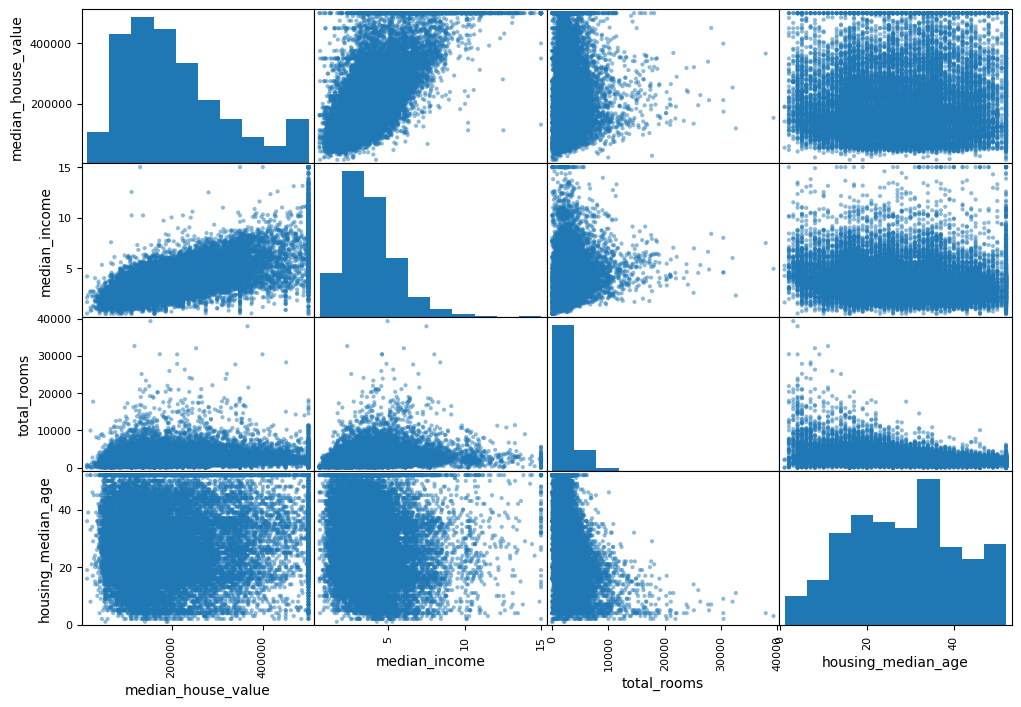

In [13]:
from pandas.plotting import scatter_matrix

attributes = ["median_house_value", "median_income", "total_rooms", "housing_median_age"]
scatter_matrix(raw_data[attributes], figsize=(12, 8))
plt.show()